In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator

In [2]:
Voltage_Array = [1, 0.9, 0.8, 0.7, 0.6, 0.5]
Tops_Array = [np.NaN, 4.37, 3.73, 2.94, 2.18, np.NaN]
TopsW_Array = [np.NaN, 208, 261, 286, 419, np.NaN]
STD_Array = [np.NaN, 0.56, 0.79, 0.86, 1.64, np.NaN]
max_freqs = [40, 36.36, 34.54, 21.8, 10.9, 0]

In [3]:
# Define frequency sweep grid for plotting (from min to max)
freq_grid = np.linspace(0, 50, 500)  # 0–50 MHz at high resolution
from matplotlib.colors import ListedColormap
# Build pass/fail matrix
results = np.zeros((len(freq_grid), len(Voltage_Array)), dtype=int)
for i, v in enumerate(Voltage_Array):
    results[:, i] = (freq_grid <= max_freqs[i]).astype(int)  # 1=pass, 0=fail

# Color map
cmap = ListedColormap(['red', 'green'])

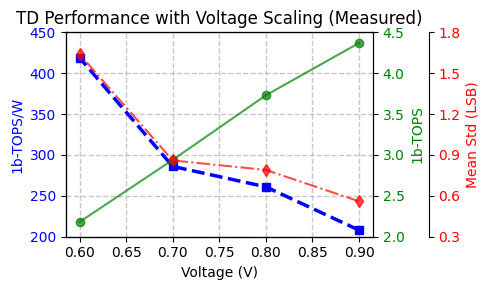

In [4]:
# Create base figure and first axis
fig, ax1 = plt.subplots(figsize=(5, 3))



# First y-axis (left)
#ax1.plot(Voltage_Array, Tops_Array, 'o-', color='tab:blue', linewidth=2, label='Tops')
ax1.plot(Voltage_Array, TopsW_Array, 's--', color='b', linewidth=2.5, label='1b-TOPS/W')
ax1.set_xlabel('Voltage (V)')
ax1.set_ylabel('1b-TOPS/W', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_ylim(200, 450)
ax1.yaxis.set_major_locator(MultipleLocator(50))

# Second y-axis (right)
ax2 = ax1.twinx()
ax2.plot(Voltage_Array, Tops_Array, 'o-', color='g', linewidth=1.5, alpha=0.7,label='1b-TOPS')
ax2.set_ylabel('1b-TOPS', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim(2, 4.5)
ax2.yaxis.set_major_locator(MultipleLocator(0.5))

# Third y-axis (shifted)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 40))  # shift outward to avoid overlap
ax3.plot(Voltage_Array, STD_Array, 'd-.', color='r', linewidth=1.5, alpha=0.7,label='Mean Std (LSB)')
ax3.set_ylabel('Mean Std (LSB)', color='r')
ax3.tick_params(axis='y', labelcolor='r')
ax3.set_ylim(0.3, 1.8)
ax3.yaxis.set_major_locator(MultipleLocator(0.3))

# Title and grid
plt.title('TD Performance with Voltage Scaling (Measured)')
ax1.grid(True, which='major', linestyle='--', linewidth=1, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=1, alpha=0.5)

# Combine legends
lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [line.get_label() for line in lines]
#ax1.legend(lines, labels, loc='upper left')



plt.tight_layout()
#plt.savefig("D:\ISSCC_26\Graphs\TOPS_Watt_Voltage.jpg",dpi=800, bbox_inches="tight", transparent=True)
plt.show()

C:\Users\91880\AppData\Local\Temp\ipykernel_44544\2247976222.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


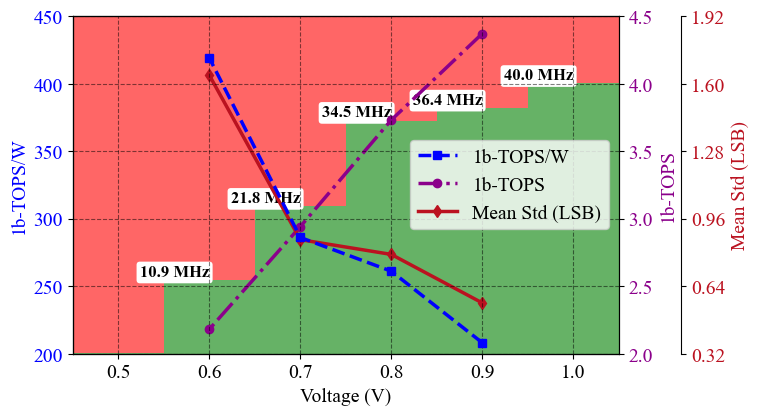

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MultipleLocator

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['font.family'] = 'Times New Roman'   # or 'Times New Roman', 'DejaVu Sans', etc.
mpl.rcParams['font.size'] = 14

# Axis-specific defaults
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 14

# ---------------------------------------------
# Shmoo Data
# ---------------------------------------------
voltages   = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
max_freqs  = np.array([0, 10.9, 21.8, 34.54, 36.36, 40.0])  # MHz
freq_grid  = np.linspace(0, 50, 500)

results = np.zeros((len(freq_grid), len(voltages)), dtype=int)
for i, v in enumerate(voltages):
    results[:, i] = (freq_grid <= max_freqs[i]).astype(int)

cmap = ListedColormap(['red', 'green'])

# ---------------------------------------------
# Performance Data
# ---------------------------------------------
Voltage_Array = np.array([1, 0.9, 0.8, 0.7, 0.6, 0.5])
Tops_Array    = np.array([np.NaN, 4.37, 3.73, 2.94, 2.18, np.NaN])
TopsW_Array   = np.array([np.NaN, 208, 261, 286, 419, np.NaN])
STD_Array     = np.array([np.NaN, 0.56, 0.79, 0.86, 1.64, np.NaN])

# ---------------------------------------------
# Figure + axes
# ---------------------------------------------
fig = plt.figure(figsize=(7, 4.5))

# Main axes for performance curves
ax_perf = fig.add_axes([0.12, 0.15, 0.78, 0.75])

# Shmoo axes (background)
ax_shmoo = fig.add_axes(ax_perf.get_position(), sharex=ax_perf)
ax_shmoo.set_zorder(0)
ax_shmoo.patch.set_alpha(1.0)

# Shmoo background
ax_shmoo.pcolormesh(
    voltages, freq_grid, results,
    cmap=cmap, shading=None, alpha=0.6
)
ax_shmoo.set_ylim(0, 50)

# Hide frequency axis and ticks
ax_shmoo.axis('off')

# ✅ Place frequency text at actual max_freq positions
for v, f in zip(voltages, max_freqs):
    if f > 0:  # skip zero-frequency cases
        ax_shmoo.text(
            v, f, f"{f:.1f} MHz",
            ha='right', va='bottom',
            fontsize=12, color='black',
            fontweight='bold',
            alpha=1,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=1, zorder=6)
        )

# ---------------------------------------------
# Performance Curves
# ---------------------------------------------
ax_perf.set_facecolor('none')
ax_perf.set_zorder(1)

# TOPS/W (Left)
ax1 = ax_perf
ax1.plot(Voltage_Array, TopsW_Array, 's--', color='b', linewidth=2.5, label='1b-TOPS/W', zorder=3)
ax1.set_xlabel('Voltage (V)',fontsize=14)
ax1.set_ylabel('1b-TOPS/W', color='b',fontsize=14)
ax1.tick_params(axis='y', labelcolor='b',labelsize=14)
ax1.tick_params(axis='x', labelcolor='black',labelsize=14)
ax1.set_ylim(200, 450)
ax1.yaxis.set_major_locator(MultipleLocator(50))
ax1.set_xticks(voltages)

# TOPS (Right)
ax2 = ax1.twinx()
ax2.plot(Voltage_Array, Tops_Array, 'o-.', color='#8B008B', linewidth=2.5, alpha=1, label='1b-TOPS', zorder=4)
ax2.set_ylabel('1b-TOPS', color='#8B008B',fontsize=14)
ax2.tick_params(axis='y', labelcolor='#8B008B',labelsize=14)
ax2.set_ylim(2, 4.5)
ax2.yaxis.set_major_locator(MultipleLocator(0.5))
ax2.patch.set_alpha(0)

# STD (Right, shifted)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 45))
ax3.plot(Voltage_Array, STD_Array, 'd-', color="#BB1220", linewidth=2.5, alpha=1, label='Mean Std (LSB)', zorder=5)
ax3.set_ylabel('Mean Std (LSB)', color='#BB1220',fontsize=14)
ax3.tick_params(axis='y', labelcolor='#BB1220',labelsize=14)
ax3.set_ylim(0.32, 0.32 + 0.32*5)
ax3.yaxis.set_major_locator(MultipleLocator(0.32))
ax3.patch.set_alpha(0)

# ---------------------------------------------
# Legend and finishing touches
# ---------------------------------------------
lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc = "center right")

ax1.grid(True, linestyle='--', alpha=0.5, zorder=6,color='black')
#plt.title('TD Performance with Voltage (Measured)',fontsize=15)

plt.tight_layout()
plt.savefig("D:\ISSCC_26\Graphs\TOPS_Watt_Voltage.jpg",dpi=800, bbox_inches="tight", transparent=True)
plt.show()
